In [1]:
import nltk
import numpy as np
import pandas as pd

In [2]:
from nltk.corpus import movie_reviews
#from utils import process_reviews, build_freqs

In [3]:
nltk.download('movie_reviews')

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


True

In [4]:
pos_fileids = movie_reviews.fileids('pos')
neg_fileids = movie_reviews.fileids('neg')

all_positive_reviews = [movie_reviews.raw(fileid) for fileid in pos_fileids]
all_negative_reviews = [movie_reviews.raw(fileid) for fileid in neg_fileids]

In [5]:
len(all_positive_reviews)


1000

In [6]:
len(all_negative_reviews)

1000

In [7]:
test_pos = all_positive_reviews[800:]
train_pos = all_positive_reviews[:800]
test_neg = all_negative_reviews[800:]
train_neg = all_negative_reviews[:800]

In [8]:
train_x = train_pos + train_neg
test_x = test_pos + test_neg

train_y = np.append(np.ones(len(train_pos)), np.zeros(len(train_neg)))
test_y = np.append(np.ones(len(test_pos)), np.zeros(len(test_neg)))

In [9]:
len(train_x)

1600

In [10]:
train_x[0]

'films adapted from comic books have had plenty of success , whether they\'re about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there\'s never really been a comic book like from hell before . \nfor starters , it was created by alan moore ( and eddie campbell ) , who brought the medium to a whole new level in the mid \'80s with a 12-part series called the watchmen . \nto say moore and campbell thoroughly researched the subject of jack the ripper would be like saying michael jackson is starting to look a little odd . \nthe book ( or " graphic novel , " if you will ) is over 500 pages long and includes nearly 30 more that consist of nothing but footnotes . \nin other words , don\'t dismiss this film because of its source . \nif you can get past the whole comic book thing , you might find another stumbling block in from hell\'s directors , albert and allen hughes . \ngetting the hughes brothers to direct this seem

In [11]:
train_x[1599]

' * * * be warned . . . \nthe following review contains some harsh language * * * \nthe blair witch project . \nquite possibly the least scariest movie of all time . \nif you want to see real terror on the big screen go back and watch any scene with jar jar binks in the phantom menace , because this movie is not scary or even remotely creepy . \nmy colleague and friend chuck dowling wrote that if less is more , then the blair witch filmmakers must have thought that nothing is more . \nand this worked for him . \nwell , i\'m sorry , but nothing . . . \nis nothing ! ! ! ! ! \nnothing is not more . \nit\'s nothiiiiiinggggggggggg ! ! ! ! ! ! . \ni do not pay 5 dollars to see nothing . \n " nothing " is free , available all around the world at a location near you . \ni am absolutely in amazement that some people find this movie scary . \ni could just discount them and say , " well , i guess they are just pansy chicken shits who are probably scared of their own shadow . " \nbut i have intell

In [12]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

In [13]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
def process_review(review):
    """
    Очищення тексту, токенізація, видалення стоп-слів та стемінг

    """

    stemmer = PorterStemmer()
    stopwords_english = stopwords.words('english')
    review = re.sub(r'\$\w*', '', review)
    review = re.sub(r'^RT[\s]+', '', review)
    review = re.sub(r'https?://[^\s\n\r]+', '', review)
    review = re.sub(r'#', '', review)
    tokenizer = TweetTokenizer(
        preserve_case=False, strip_handles=True, reduce_len=True
    )
    review_tokens = tokenizer.tokenize(review)

    reviews_clean = []
    for word in review_tokens:
        if (
            word not in stopwords_english
            and any(ch.isalpha() for ch in word)
        ):
            stem_word = stemmer.stem(word)
            reviews_clean.append(stem_word)

    return reviews_clean

In [15]:
train_x[0]

'films adapted from comic books have had plenty of success , whether they\'re about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there\'s never really been a comic book like from hell before . \nfor starters , it was created by alan moore ( and eddie campbell ) , who brought the medium to a whole new level in the mid \'80s with a 12-part series called the watchmen . \nto say moore and campbell thoroughly researched the subject of jack the ripper would be like saying michael jackson is starting to look a little odd . \nthe book ( or " graphic novel , " if you will ) is over 500 pages long and includes nearly 30 more that consist of nothing but footnotes . \nin other words , don\'t dismiss this film because of its source . \nif you can get past the whole comic book thing , you might find another stumbling block in from hell\'s directors , albert and allen hughes . \ngetting the hughes brothers to direct this seem

In [16]:
process_review(train_x[0])

['film',
 'adapt',
 'comic',
 'book',
 'plenti',
 'success',
 'whether',
 'superhero',
 'batman',
 'superman',
 'spawn',
 'gear',
 'toward',
 'kid',
 'casper',
 'arthous',
 'crowd',
 'ghost',
 'world',
 "there'",
 'never',
 'realli',
 'comic',
 'book',
 'like',
 'hell',
 'starter',
 'creat',
 'alan',
 'moor',
 'eddi',
 'campbel',
 'brought',
 'medium',
 'whole',
 'new',
 'level',
 'mid',
 '80',
 'part',
 'seri',
 'call',
 'watchmen',
 'say',
 'moor',
 'campbel',
 'thoroughli',
 'research',
 'subject',
 'jack',
 'ripper',
 'would',
 'like',
 'say',
 'michael',
 'jackson',
 'start',
 'look',
 'littl',
 'odd',
 'book',
 'graphic',
 'novel',
 'page',
 'long',
 'includ',
 'nearli',
 'consist',
 'noth',
 'footnot',
 'word',
 'dismiss',
 'film',
 'sourc',
 'get',
 'past',
 'whole',
 'comic',
 'book',
 'thing',
 'might',
 'find',
 'anoth',
 'stumbl',
 'block',
 "hell'",
 'director',
 'albert',
 'allen',
 'hugh',
 'get',
 'hugh',
 'brother',
 'direct',
 'seem',
 'almost',
 'ludicr',
 'cast',
 '

In [17]:
train_y

array([1., 1., 1., ..., 0., 0., 0.])

In [18]:
len(train_y)

1600

In [19]:
def build_freqs(reviews, ys):
    """
    Побудова словника частотностей для пар

    """
    yslist = np.squeeze(ys).astype(int).tolist()
    freqs = {}
    for y, review in zip(yslist, reviews):
        for word in process_review(review):
            pair = (word, y)
            freqs[pair] = freqs.get(pair, 0) + 1
    return freqs

In [20]:
freqs = build_freqs(train_x, train_y)

In [21]:
len(freqs)

43376

In [22]:
pos_top = sorted([(w, c) for (w, y), c in freqs.items() if y == 1], key=lambda t: -t[1])
neg_top = sorted([(w, c) for (w, y), c in freqs.items() if y == 0], key=lambda t: -t[1])

In [23]:
print("Слів у позитивному класі:", len(pos_top))

Слів у позитивному класі: 22283


In [24]:
print("Слів у негативному класі:", len(neg_top))

Слів у негативному класі: 21093


In [25]:
print("Позитивний клас, найчастіші:", pos_top[:15])

Позитивний клас, найчастіші: [('film', 4635), ('one', 2407), ('movi', 2377), ('like', 1550), ('charact', 1546), ('make', 1299), ('time', 1219), ('get', 1199), ('stori', 1082), ('scene', 1051), ('see', 1002), ('play', 979), ('good', 973), ('also', 959), ('even', 950)]


In [26]:
print("Позитивний клас, найрідші:", pos_top[-15:])

Позитивний клас, найрідші: [('perjur', 1), ('good-guy', 1), ('frown', 1), ('grizzli', 1), ('affair-a-week', 1), ('venora', 1), ('oakland', 1), ('death-row', 1), ("pocum'", 1), ('rack', 1), ('crinkl', 1), ('break-out', 1), ('high-spe', 1), ("governer'", 1), ('tension-build', 1)]


In [27]:
print("Негативний клас, найчастіші:", neg_top[:15])

Негативний клас, найчастіші: [('film', 3806), ('movi', 2828), ('one', 2121), ('like', 1652), ('charact', 1394), ('get', 1367), ('make', 1180), ('even', 1106), ('time', 1094), ('scene', 1032), ('good', 951), ('play', 922), ('would', 833), ('bad', 821), ('look', 801)]


In [28]:
print("Негативний клас, найрідші:", neg_top[-15:])

Негативний клас, найрідші: [('grouch', 1), ('unwork', 1), ('jailbird', 1), ('pantomin', 1), ('henpeck', 1), ('bink', 1), ('nothiiinggg', 1), ('pansi', 1), ('pisspoor', 1), ('tinkertoy', 1), ('backpack', 1), ('filmgo', 1), ('cant', 1), ('shakycam', 1), ('quibbl', 1)]


In [29]:
def sigmoid(z):
    h = 1 / (1 + np.exp(-z))
    return h

In [30]:
result = []

for z in np.arange(-10, 10, 0.1):
    result.append(sigmoid(z))

In [31]:
result

[np.float64(4.5397868702434395e-05),
 np.float64(5.0172164683764205e-05),
 np.float64(5.5448524722794907e-05),
 np.float64(6.127973961660237e-05),
 np.float64(6.772414961977011e-05),
 np.float64(7.48462275106111e-05),
 np.float64(8.271722285166624e-05),
 np.float64(9.141587385216126e-05),
 np.float64(0.00010102919390777254),
 np.float64(0.00011165334062956235),
 np.float64(0.0001233945759862313),
 np.float64(0.00013637032707949654),
 np.float64(0.00015071035805975686),
 np.float64(0.0001665580647773352),
 np.float64(0.00018407190496342303),
 np.float64(0.00020342697805520542),
 np.float64(0.0002248167702332941),
 np.float64(0.00024845508183933296),
 np.float64(0.00027457815610133096),
 np.float64(0.00030344703002891705),
 np.float64(0.0003353501304664757),
 np.float64(0.0003706061406263939),
 np.float64(0.0004095671649860472),
 np.float64(0.0004526222232405314),
 np.float64(0.0005002011070795599),
 np.float64(0.0005527786369235946),
 np.float64(0.0006108793594343956),
 np.float64(0.000

In [32]:
from matplotlib import pyplot as p

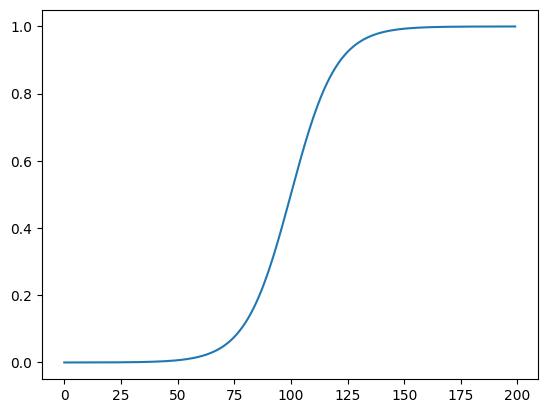

In [33]:
p.plot(result)

In [34]:
def gradientDescent(x, y, theta, alpha, num_iters):
    m = x.shape[0]
    y = y.reshape(-1, 1)
    history = []
    for i in range(num_iters):
        h = sigmoid(np.dot(x, theta))
        h_safe = np.clip(h, 1e-15, 1 - 1e-15)
        J = (-1/m) * np.sum(y * np.log(h_safe) + (1-y) * np.log(1 - h_safe))
        theta = theta - (alpha/m) * np.dot(x.T, (h - y))
        history.append(J)
    return J, theta, history

In [35]:
N_pos = sum(v for (w, y), v in freqs.items() if y == 1)
N_neg = sum(v for (w, y), v in freqs.items() if y == 0)
V = len({w for (w, y) in freqs})

In [36]:
def extract_features(review, freqs):
    words = process_review(review)
    x = np.zeros((1, 5))
    x[0, 0] = 1.0
    if not words:
        return x
    pos_s = neg_s = lo = strong = 0.0
    for w in words:
        p = freqs.get((w, 1), 0)
        n = freqs.get((w, 0), 0)
        pol = (p - n) / (p + n + 1)
        pos_s += max(pol, 0)
        neg_s += max(-pol, 0)
        lo += np.log((p + 1) / (N_pos + V)) - np.log((n + 1) / (N_neg + V))
        strong += (pol > 0.3) - (pol < -0.3)
    m = len(words)
    x[0, 1] = pos_s / m
    x[0, 2] = neg_s / m
    x[0, 3] = lo / m
    x[0, 4] = strong / m
    return x

In [37]:
X = np.vstack([extract_features(r, freqs) for r in train_x])
mu, sigma = X[:, 1:].mean(axis=0), X[:, 1:].std(axis=0)
X[:, 1:] = (X[:, 1:] - mu) / sigma

In [38]:
def predict_review(review, freqs, theta):
    x = extract_features(review, freqs)
    x[:, 1:] = (x[:, 1:] - mu) / sigma
    return sigmoid(np.dot(x, theta))


In [39]:
freqs

{('film', 1): 4635,
 ('adapt', 1): 68,
 ('comic', 1): 216,
 ('book', 1): 184,
 ('plenti', 1): 65,
 ('success', 1): 218,
 ('whether', 1): 106,
 ('superhero', 1): 12,
 ('batman', 1): 39,
 ('superman', 1): 5,
 ('spawn', 1): 17,
 ('gear', 1): 17,
 ('toward', 1): 137,
 ('kid', 1): 234,
 ('casper', 1): 7,
 ('arthous', 1): 2,
 ('crowd', 1): 40,
 ('ghost', 1): 66,
 ('world', 1): 534,
 ("there'", 1): 337,
 ('never', 1): 552,
 ('realli', 1): 632,
 ('like', 1): 1550,
 ('hell', 1): 81,
 ('starter', 1): 3,
 ('creat', 1): 285,
 ('alan', 1): 46,
 ('moor', 1): 35,
 ('eddi', 1): 49,
 ('campbel', 1): 42,
 ('brought', 1): 72,
 ('medium', 1): 20,
 ('whole', 1): 177,
 ('new', 1): 568,
 ('level', 1): 113,
 ('mid', 1): 11,
 ('80', 1): 25,
 ('part', 1): 375,
 ('seri', 1): 208,
 ('call', 1): 274,
 ('watchmen', 1): 1,
 ('say', 1): 480,
 ('thoroughli', 1): 26,
 ('research', 1): 27,
 ('subject', 1): 110,
 ('jack', 1): 129,
 ('ripper', 1): 5,
 ('would', 1): 808,
 ('michael', 1): 161,
 ('jackson', 1): 50,
 ('start'

In [64]:
X.shape

(1600, 5)

In [41]:
X[:5]

array([[ 1.        ,  0.18455983, -0.50079107,  0.24167889,  0.436649  ],
       [ 1.        ,  0.72891981, -0.66059697,  0.75142132,  0.83293551],
       [ 1.        , -0.24144569, -0.9135755 ,  0.27338899,  0.21291856],
       [ 1.        ,  0.98710001, -1.02078236,  0.98964739,  1.09025024],
       [ 1.        ,  0.14650681, -0.56844787,  0.29070268,  0.68885501]])

In [42]:
train_x[:5]

['films adapted from comic books have had plenty of success , whether they\'re about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there\'s never really been a comic book like from hell before . \nfor starters , it was created by alan moore ( and eddie campbell ) , who brought the medium to a whole new level in the mid \'80s with a 12-part series called the watchmen . \nto say moore and campbell thoroughly researched the subject of jack the ripper would be like saying michael jackson is starting to look a little odd . \nthe book ( or " graphic novel , " if you will ) is over 500 pages long and includes nearly 30 more that consist of nothing but footnotes . \nin other words , don\'t dismiss this film because of its source . \nif you can get past the whole comic book thing , you might find another stumbling block in from hell\'s directors , albert and allen hughes . \ngetting the hughes brothers to direct this see

In [43]:
X[1595:]

array([[ 1.        , -1.18960992,  0.11844238, -0.73524531, -0.59646021],
       [ 1.        , -0.35092078,  0.02403228, -0.17795162, -0.18249859],
       [ 1.        , -0.80439215,  1.51574477, -1.05774694, -1.14891399],
       [ 1.        , -0.87526382,  0.05271532, -0.50344555, -0.66790053],
       [ 1.        , -1.05802458,  0.21661261, -0.67269262, -0.59742887]])

In [44]:
train_x[1595:]

["mr . bean , a bumbling security guard from england is sent to la to help with the grandiose homecoming of a masterpiece american painting . \nthe first two words should have said enough to let you know what occurs during bean's trip to la , but if they didn't look out because you are in for a rather interesting if not odd ride . \nheck depending on your humor you might end up laughing through the whole flick . \neither way look out america bean is coming . \nwell , what can really be said about this movie , there is very little discernible plot . \nthat much is not hard to grapple with for it is a slapstick comedy . \nit achieves that goal rather admirably , but because it is that , the plot is just screaming for help . \nthe whole premise that the movie is based on is to say the least flawed . \nthe movie had its funny moments but there was no real story line other than something that could be thought up on a whim and carried through and in many causes ad-libbed as you went . \ndon'

In [45]:
Y = train_y.reshape(-1, 1)

In [46]:
Y.shape

(1600, 1)

**Проведемо дослідження впливу швидкості навчання, кількості ітерацій та порогу класифікації на збіжність і точність моделі.**

In [47]:
from matplotlib import pyplot as plt

In [48]:
def acc(X_, y_, th, thr=0.5):
    return np.mean((sigmoid(X_ @ th) > thr).astype(int).ravel() == y_.ravel())

def cost(X_, y_, th):
    h = np.clip(sigmoid(X_ @ th), 1e-15, 1 - 1e-15)
    return float(-np.mean(y_ * np.log(h) + (1 - y_) * np.log(1 - h)))

rng = np.random.RandomState(42)
perm = rng.permutation(len(X))
cut = int(0.8 * len(X))
X_tr, X_val = X[perm[:cut]], X[perm[cut:]]
Y_tr, Y_val = Y[perm[:cut]], Y[perm[cut:]]
theta0 = np.zeros((X.shape[1], 1))

alpha=0.0001: J=0.6227, точність train=0.9773, val=0.9906
alpha=0.001: J=0.3265, точність train=0.9773, val=0.9906
alpha=0.01: J=0.1024, точність train=0.9797, val=0.9906
alpha=0.1: J=0.0607, точність train=0.9805, val=0.9906
alpha=1: J=0.0519, точність train=0.9836, val=0.9844
alpha=10: J=0.0416, точність train=0.9875, val=0.9812


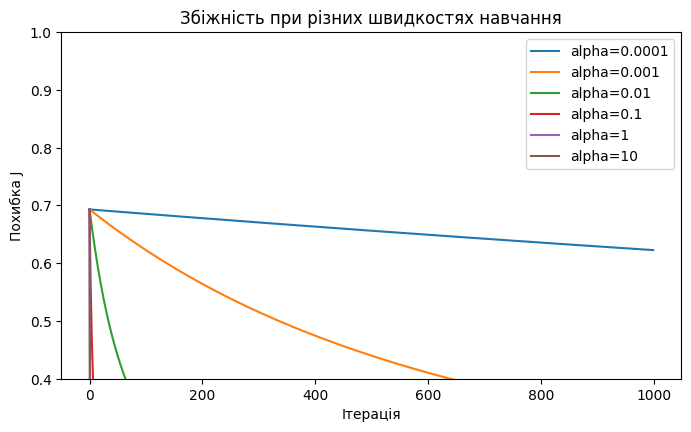

In [49]:
alphas = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
plt.figure(figsize=(8, 4.5))
for a in alphas:
    J_, th, hist = gradientDescent(X_tr, Y_tr, theta0, a, 1000)
    print(f"alpha={a}: J={J_:.4f}, точність train={acc(X_tr, Y_tr, th):.4f}, val={acc(X_val, Y_val, th):.4f}")
    plt.plot(hist, label=f"alpha={a}")
plt.xlabel("Ітерація"); plt.ylabel("Похибка J")
plt.ylim(0.4, 1.0); plt.legend(); plt.title("Збіжність при різних швидкостях навчання")
plt.show()


iters=10: J_train=0.0964, J_val=0.0842, val acc=0.9906
iters=50: J_train=0.0657, J_val=0.0494, val acc=0.9906
iters=100: J_train=0.0607, J_val=0.0429, val acc=0.9906
iters=300: J_train=0.0564, J_val=0.0381, val acc=0.9906
iters=500: J_train=0.0546, J_val=0.0374, val acc=0.9875
iters=1000: J_train=0.0519, J_val=0.0377, val acc=0.9844
iters=1250: J_train=0.0510, J_val=0.0380, val acc=0.9844
iters=2000: J_train=0.0491, J_val=0.0387, val acc=0.9812
iters=3000: J_train=0.0474, J_val=0.0393, val acc=0.9812


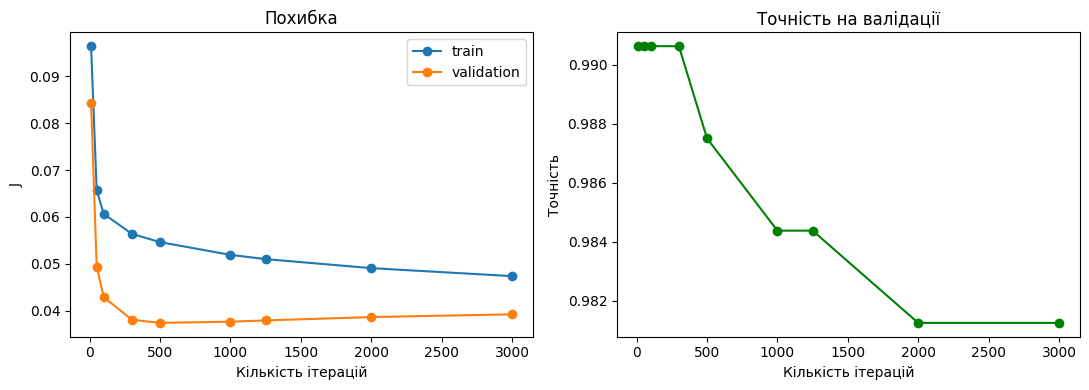

In [50]:
best_alpha = 1.0
iters_list = [10, 50, 100, 300, 500, 1000, 1250, 2000, 3000]
tr_loss, val_loss, val_acc = [], [], []
for n in iters_list:
    _, th, _ = gradientDescent(X_tr, Y_tr, theta0, best_alpha, n)
    tr_loss.append(cost(X_tr, Y_tr, th))
    val_loss.append(cost(X_val, Y_val, th))
    val_acc.append(acc(X_val, Y_val, th))
    print(f"iters={n}: J_train={tr_loss[-1]:.4f}, J_val={val_loss[-1]:.4f}, val acc={val_acc[-1]:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(iters_list, tr_loss, marker="o", label="train")
ax[0].plot(iters_list, val_loss, marker="o", label="validation")
ax[0].set_xlabel("Кількість ітерацій"); ax[0].set_ylabel("J"); ax[0].legend(); ax[0].set_title("Похибка")
ax[1].plot(iters_list, val_acc, marker="o", color="green")
ax[1].set_xlabel("Кількість ітерацій"); ax[1].set_ylabel("Точність"); ax[1].set_title("Точність на валідації")
plt.tight_layout(); plt.show()

In [51]:
_, th, _ = gradientDescent(X_tr, Y_tr, theta0, best_alpha, 1000)
for thr in [0.3, 0.4, 0.5, 0.6, 0.65, 0.7]:
    print(f"поріг={thr}: val acc={acc(X_val, Y_val, th, thr):.4f}")

поріг=0.3: val acc=0.9844
поріг=0.4: val acc=0.9812
поріг=0.5: val acc=0.9844
поріг=0.6: val acc=0.9875
поріг=0.65: val acc=0.9875
поріг=0.7: val acc=0.9875


In [61]:
X_test = np.vstack([extract_features(r, freqs) for r in test_x])
X_test[:, 1:] = (X_test[:, 1:] - mu) / sigma

In [62]:
for a in [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]:
    J_, th, hist = gradientDescent(X, Y, theta0, a, 1000)
    print(f"alpha={a}: J={J_:.4f}, train={acc(X, Y, th):.4f}, test={acc(X_test, test_y, th):.4f}")

alpha=0.0001: J=0.6220, train=0.9794, test=0.7925
alpha=0.001: J=0.3245, train=0.9800, test=0.7975
alpha=0.01: J=0.0998, train=0.9819, test=0.8000
alpha=0.1: J=0.0569, train=0.9825, test=0.7950
alpha=1: J=0.0495, train=0.9838, test=0.7925
alpha=10: J=0.0411, train=0.9856, test=0.7725


In [63]:
for n in [10, 50, 100, 300, 500, 1000, 1250, 2000, 3000]:
    _, th, _ = gradientDescent(X, Y, theta0, 0.1, n)
    print(f"iters={n}: J={cost(X, Y, th):.4f}, test={acc(X_test, test_y.reshape(-1,1), th):.4f}")

iters=10: J=0.3179, test=0.7925
iters=50: J=0.1360, test=0.7975
iters=100: J=0.0993, test=0.8000
iters=300: J=0.0695, test=0.7975
iters=500: J=0.0625, test=0.7975
iters=1000: J=0.0569, test=0.7950
iters=1250: J=0.0558, test=0.7975
iters=2000: J=0.0540, test=0.7975
iters=3000: J=0.0528, test=0.7975


Шляхом зміни швидкості навчання та кількості ітерацій було встановлено, що при малих alpha (1e-4, 1e-3) модель недонавчена (J = 0.62 і 0.32), а при alpha = 10 точність на тесті помітно падає (0.76). Найкращий компроміс між похибкою та точністю дає alpha = 0.1 (J = 0.056, точність на тесті 0.80). Збільшення кількості ітерацій понад 1000 майже не зменшує похибку, а точність на тесті не зростає (0.7925 при 3000), тому обрано 1000 ітерацій.

In [53]:
J, theta, history = gradientDescent(X, Y, np.zeros((X.shape[1], 1)), 0.1, 1000)
print(f"Помилка після навчання: {J:.8f}.")
print(f"Вектор вагових коефіцієнтів: {[round(t, 8) for t in np.squeeze(theta)]}")


Помилка після навчання: 0.05694677.
Вектор вагових коефіцієнтів: [np.float64(0.08518801), np.float64(1.40655619), np.float64(-2.03654236), np.float64(1.54036877), np.float64(1.83246004)]


In [54]:
review = all_positive_reviews[0]

review

'films adapted from comic books have had plenty of success , whether they\'re about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there\'s never really been a comic book like from hell before . \nfor starters , it was created by alan moore ( and eddie campbell ) , who brought the medium to a whole new level in the mid \'80s with a 12-part series called the watchmen . \nto say moore and campbell thoroughly researched the subject of jack the ripper would be like saying michael jackson is starting to look a little odd . \nthe book ( or " graphic novel , " if you will ) is over 500 pages long and includes nearly 30 more that consist of nothing but footnotes . \nin other words , don\'t dismiss this film because of its source . \nif you can get past the whole comic book thing , you might find another stumbling block in from hell\'s directors , albert and allen hughes . \ngetting the hughes brothers to direct this seem

In [55]:
predict_review(review, freqs, theta)

array([[0.92670076]])

In [56]:
if  predict_review(review, freqs, theta) >= 0.5:
  print ('позитивний')
else:
  print ('негативний')

позитивний


In [57]:
def test_logistic_regression(test_x, test_y, freqs, theta):
    y_hat = []
    for review in test_x:
        y_pred = predict_review(review, freqs, theta)
        if y_pred > 0.5:
            y_hat.append(1)
        else:
            y_hat.append(0)
    accuracy = (np.sum(np.array(y_hat)==np.squeeze(test_y)))/len(test_x)
    return accuracy

tmp_accuracy = test_logistic_regression(test_x, test_y, freqs, theta)
print(f"Точність логістичної регресії: {tmp_accuracy:.4f}")


Точність логістичної регресії: 0.7950


In [58]:
test_mov="When you look at the first two Tom Holland-starrer Spider-Man movies, they had a breezy feel similar to the character’s emotional maturity. Those movies were ultimately those fun popcorn entertainers. In my opinion, the real balance between emotional highs and visual spectacle was achieved in Spider-Man: No Way Home, where things went far beyond the so-called fan service. The inclusion of all the Spidermen was used effectively, rather than as a creative gimmick. The latest movie in the franchise, Spider-Man: Brand New Day, also wants to tap into a similar space where the loneliness of the character adds to the depth, and his powers add to the fun part of it. But somewhere the plot felt a bit restricted and almost made me feel the purpose of the movie was to introduce multiple characters rather than exploring Peter Parker in his new circumstances. As most of you may know, after the events in No Way Home, Peter is now living that lonely life where nobody really knows him. He is that crime-fighting friendly vigilante whom the police love, and under his watch the city is a safe space. At one point during his missions, Spider-Man encounters a new kind of threat who was invisible and was trying to attack this facility called the Department of Damage Control, a SHIELD subunit that was formed in the aftermath of the Battle of New York. Who this new threat is and what they want is what we see in this movie. I am not really a comic book nerd, and my knowledge and enthusiasm about these movies and characters comes from the movies and shows I have watched, including the MCU films and other franchises like X-Men. If you look at the Tom Holland-starrer franchise, it never really had that origin story kind of beginning, as he was introduced to us in the middle of Civil War as Tony Stark’s prodigy. The memory-erasing spell actually gives the movie a space to reset things and give it the elements of an origin story. The quintessential scene of the hero realizing his superpowers is shown in this movie in a different scenario. And if you look at it, the movie has many scenes that are like a tribute to many of the iconic moments in the MCU. Captain America waking up from the deep sleep, the Hulk smashing the Chitauri army on New York buildings, and the Hulk’s thunderclap are all sort of recreated in this movie with the same or different characters. So on that level, this movie, celebrating the 26-year-old legacy of the franchise, is helping it be an entertainer to MCU fans. But this is ultimately a Spider-Man movie, and there is a reason why it has done a phenomenal pre-release business, and that is the fan following this character has beyond the MCU. There is a phase towards the end where we see a parallel between the antagonist and protagonist, and that was perhaps the only area where the idea of Spider-Man was getting explored in the movie. The screenplay is, in a way, burdened with the responsibility of adding too many characters to make this an MCU film. And the biggest example of that was the Hulk. Even though that visual of his face filling the whole screen was a staggering one, at the end of the movie, the character rarely felt relevant. Even though the character’s tone has significantly changed, The Punisher was still useful to the plot. Another major letdown, largely due to the unnecessary hype, was The Hand. While the second half of that fight sequence between them and Peter was stunning, much like Hulk, those characters rarely stay with you."

p = predict_review(test_mov, freqs, theta)

if  p > 0.65:
  print ('позитивний', p)
else:
  print ('негативний', p)


позитивний [[0.83408142]]


In [59]:
test_mov="These days, it seems like Colleen Hoover is at the epicenter of media. Whether it’s the literary world or Hollywood, her books and adaptations are coming out in rapid succession, each one with an even more A-list cast to one-up the last. But no Colleen Hoover movie has had quite as much anticipation as the adaptation of her bestselling thriller, Verity. Now, before we dive into this review, I feel like in the name of journalism, I have to let you know that I am a little biased when it comes to Colleen Hoover. Whereas millions of readers have swooned over what she writes, I have yet to find a book that I…connect to. That said, of all the books of hers I’ve picked up, I can confidently say Verity is her best work by far. And after seeing Regretting You and It Ends With Us in theaters, I was honestly pleasantly surprised by how her books were adapted for the screen. If anything, her plots felt better suited for a 90-minute viewing experience than a multi-day reading one. So, I went into Verity excited to see how it would land on the big screen. Unfortunately, what I hoped would be an entertaining psychological thriller felt like a middle school production of Gone Girl. When going into this movie, I figured that even if the storyline isn’t for me, it’ll be fun to watch Anne Hathaway and Dakota Johnson on screen. And honestly, it was fun to watch Anne Hathaway and Dakota Johnson! But I didn’t feel like I was watching their characters at all. Anne Hathaway’s Verity came across as so cartoonish and over-the-top that it almost felt like an SNL parody of a villain. Which, sure, is the point to a certain extent, but it was so heavy-handed that Dakota Johnson’s Lowen falling for her ruse made her look like the worst, most naive amateur detective in the world. What kind of thriller writer doesn’t even stop for a second to consider that the most obvious explanation may not be the correct one? Her “investigating” consisted of Googling “Verity Crawford” once and running with it. She becomes incredibly attached to a family after having approximately three conversations with the father and asking the son to play twice, only to be turned down twice. Her affection for them felt out of nowhere and, in turn, made her fascination with the family feel completely unearned. It’s been a while since I’ve read the book, but I do remember being genuinely shocked by the plot twist. In the film, Verity’s lies were clear from the start, and it’s clear what they want you to believe in the manuscript-versus-letter debate. In fact, the whole “twist” didn’t really change anything."

p = predict_review(test_mov, freqs, theta)

if  p > 0.65:
  print ('позитивний', p)
else:
  print ('негативний', p)

негативний [[0.58814885]]


In [60]:
test_mov="""This saccharine, reverential biopic about controversial music legend Michael Jackson is set to be one of the worst films of 2026 – removing "everything that might be deemed dramatic". It's bad. It's bad. It's really, really bad. The new Michael Jackson biopic, Michael, is produced by several of his relatives and close associates, so no one expected it to be a searing portrait of the controversial star. But it's still surprising that they've made such a bland and barely competent daytime TV movie. A chronological plod through Jackson's time in the Jackson 5, and his subsequent solo success, the film's narrative stops in the mid-1980s, before he was accused of child abuse, and it removes everything from the story that might be deemed contentious. It removes everything that might be deemed dramatic, too. What's left is scene after scene of record-industry bigwigs telling Jackson how amazingly talented he is, and of his horrible dad (Colman Domingo, barely recognisable under prosthetic make-up) scuttling over like an evil goblin and snarling: "Remember your family, Michael!"""

p = predict_review(test_mov, freqs, theta)

if  p > 0.65:
  print ('позитивний', p)
else:
  print ('негативний', p)

негативний [[0.12493155]]
